# English-language fandom decomposition (PRD §9.17)

**Purpose:** Twitch's `language` field tags 52%/22% of Apex Legends'/
PUBG: BATTLEGROUNDS' viewers as `en` with no way to tell a US, UK,
Indian, Filipino, Canadian, or Australian audience apart
(`research/inter_esports_dynamics/notebooks/niche_membership.ipynb`'s Apex/PUBG shared-occupancy finding,
2026-09-12). This notebook runs the reusable subsystem built to fix that
-- `analysis/fandom_region_decomposition.py` -- against every subject
configured in `config/fandom_decomposition_subjects.yaml`, not a
one-off for this one pair. "Fandom," not "viewership": several
independent signals are shown side by side (Twitch viewership,
self-declared stream tags, Wikipedia pageviews, Steam reviews), never
collapsed into one number -- the same "three metrics side by side"
convention `niche_membership.ipynb` already established.

Three subjects prove three different things: `apex_legends`/`pubg` are
the motivating pair; `gta_v` proves the platform-wide (`game_id`-keyed,
not `title_id`-keyed) path works, for `research/digital_fandoms/brief.md`;
`counter_strike` cross-checks the Steam-review timezone signal against
`research/esports_lifecycle_and_maturity/notebooks/fastest_growing_cs_regions.ipynb`'s independently-derived
grassroots-tournament regional growth.

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone as _tz

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection
from analysis.fandom_region_decomposition import (
    CANDIDATE_ENGLISH_COUNTRIES,
    calibrate_timezone_curve,
    decompose_by_timezone,
    get_steam_review_hourly_series,
    get_twitch_english_hourly_series,
    load_subjects,
)

SUBJECT_IDS = ["apex_legends", "pubg", "counter_strike", "rainbow_six_siege", "valorant", "gta_v"]
subjects = load_subjects()
conn = get_connection()
calibration_curve = calibrate_timezone_curve(conn)


def _midpoint(start, end):
    """Midpoint of a data window as a tz-aware UTC datetime -- accepts
    either ISO 8601 text (captured_at) or Unix epoch ints
    (timestamp_created). decompose_by_timezone needs this to resolve each
    candidate's real, DST-aware UTC offset for the window actually being
    decomposed, not today's DST state (see that function's own docstring
    for why reference_datetime has no default)."""
    def _to_dt(x):
        if isinstance(x, str):
            return datetime.strptime(x, "%Y-%m-%dT%H:%M:%SZ").replace(tzinfo=_tz.utc)
        return datetime.fromtimestamp(x, tz=_tz.utc)
    a, b = _to_dt(start), _to_dt(end)
    return a + (b - a) / 2


calibration_curve

array([0.03297829, 0.05351601, 0.02097529, 0.0494646 , 0.01480901,
       0.00980895, 0.02128957, 0.01013591, 0.026098  , 0.03445412,
       0.01208559, 0.        , 0.027103  , 0.17779454, 0.01931244,
       0.01469302, 0.00542778, 0.02746129, 0.06264838, 0.0418571 ,
       0.04497831, 0.04700526, 0.11867572, 0.12742781])

## Signal 1 -- Twitch English viewer-time, timezone-deconvolved

Calibrated against `ja`/`ko` (Japan/Korea, UTC+9, single-timezone,
no-DST anchors -- see `analysis/fandom_region_decomposition.py`'s module
docstring for why `ru`/`de`/`fr`/`pt` are deliberately excluded from
calibration despite being usable for coarse region-tagging elsewhere).

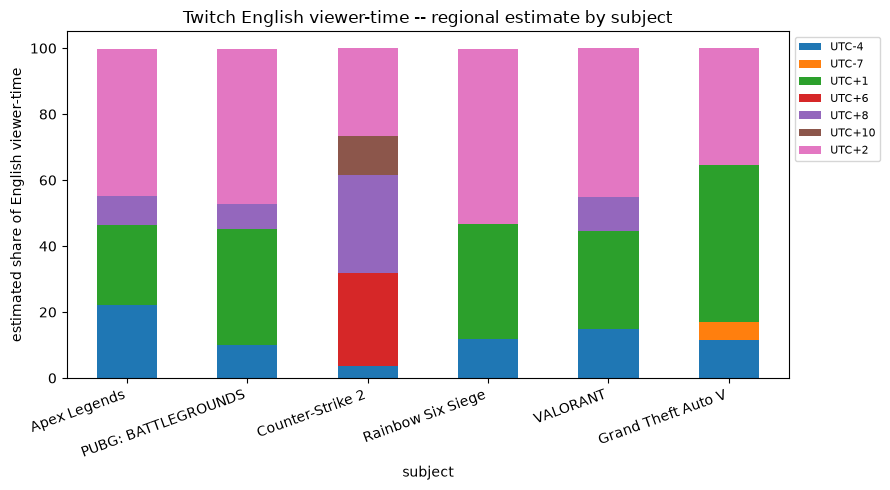

,total_english_viewer_time,UTC-4,UTC-7,UTC+1,UTC+6,UTC+8,UTC+10,UTC+2
subject,,,,,,,,
Apex Legends,1153520,22.2,0.0,24.3,0.0,8.8,0.0,44.6
PUBG: BATTLEGROUNDS,235733,10.1,0.0,35.1,0.0,7.6,0.0,47.1
Counter-Strike 2,1590840,3.5,0.0,0.0,28.2,29.9,11.8,26.7
Rainbow Six Siege,1379998,11.8,0.0,35.0,0.0,0.0,0.0,53.1
VALORANT,1735157,15.0,0.0,29.5,0.0,10.5,0.0,45.0
Grand Theft Auto V,3212014,11.4,5.6,47.5,0.0,0.0,0.0,35.5


In [2]:
twitch_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    if subject["source_table"] == "viewership_snapshots":
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM language_mix_snapshots WHERE title_id = ?", (subject["title_id"],)).fetchone()
    else:
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM platform_viewership_snapshots WHERE game_id = ?", (subject["game_id"],)).fetchone()
    hourly = get_twitch_english_hourly_series(conn, subject)
    total_english_viewer_time = int(hourly.sum())
    if w[0] is None or total_english_viewer_time == 0:
        continue
    shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve, reference_datetime=_midpoint(w[0], w[1]))
    row = {"subject": subject["display_name"], "total_english_viewer_time": total_english_viewer_time}
    row.update({country: round(share * 100, 1) for country, share in shares.items()})
    twitch_rows.append(row)

twitch_df = pd.DataFrame(twitch_rows).set_index("subject")

fig, ax = plt.subplots(figsize=(9, 5))
twitch_df.drop(columns="total_english_viewer_time").fillna(0).plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("estimated share of English viewer-time")
ax.set_title("Twitch English viewer-time -- regional estimate by subject")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
twitch_df

### Reference cities per UTC offset (interpretation aid only -- not a measured category)

Signal 1's shares above are keyed by resolved UTC offset
(`analysis/fandom_region_decomposition.py:decompose_by_timezone`, changed
2026-09-15) -- the actual thing timezone deconvolution measures, and a
label stable regardless of which candidate countries get added or
removed later. This table is a *separate*, illustrative lookup --
`reference_cities_for_offsets()` -- showing which of the current
`CANDIDATE_ENGLISH_COUNTRIES` resolve to each offset, for this window's
DST state. Deliberately not merged into `twitch_df` above: a real,
measured category (a language code, a self-declared tag) and an
inferred bucket's illustrative examples are different kinds of things,
and mixing them into one table is exactly the overclaiming risk this
change exists to avoid.

In [3]:
from analysis.fandom_region_decomposition import reference_cities_for_offsets

# One representative window across every Signal-1 subject above, rather
# than per-subject -- all title_id/game_id subjects here draw from
# collectors that have been running since roughly the same start date, so
# their windows (and therefore resolved offsets) are effectively
# identical; recompute per-subject if that stops being true.
combined_bounds = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    if subject["source_table"] == "viewership_snapshots":
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM language_mix_snapshots WHERE title_id = ?", (subject["title_id"],)).fetchone()
    else:
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM platform_viewership_snapshots WHERE game_id = ?", (subject["game_id"],)).fetchone()
    if w[0]:
        combined_bounds.append(w)
combined_start = min(b[0] for b in combined_bounds)
combined_end = max(b[1] for b in combined_bounds)
reference_table = reference_cities_for_offsets(CANDIDATE_ENGLISH_COUNTRIES, _midpoint(combined_start, combined_end))
pd.Series(reference_table, name="example_cities_at_this_offset").sort_index()

UTC+1     London/Lagos
UTC+10          Sydney
UTC+2     Johannesburg
UTC+6          Kolkata
UTC+8           Manila
UTC-4         New York
UTC-7      Los Angeles
Name: example_cities_at_this_offset, dtype: str

## Signal 2 -- self-declared region tags (`etl/extract_stream_region_tags.py`)

A completely different mechanism from timezone deconvolution -- a
streamer or their tournament organizer explicitly labeling a region in
the stream's own tags/title (`NA`/`EU`/`OCE`/... -- see that script's
module docstring for the real-data-validated whitelist, and why `BR` is
deliberately excluded as ambiguous between "Brazil" and "Battle
Royale"). Sparse by nature -- most streams declare no region at all --
so shown as counts, not shares, and only among each subject's own
`en`-language rows.

In [4]:
tag_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    if subject["source_table"] == "viewership_snapshots":
        query = "SELECT self_declared_region_tag, COUNT(*) FROM viewership_snapshots WHERE title_id = ? AND language = 'en' AND self_declared_region_tag IS NOT NULL GROUP BY self_declared_region_tag"
        params = (subject["title_id"],)
    else:
        query = "SELECT self_declared_region_tag, COUNT(*) FROM platform_viewership_snapshots WHERE game_id = ? AND language = 'en' AND self_declared_region_tag IS NOT NULL GROUP BY self_declared_region_tag"
        params = (subject["game_id"],)
    counts = dict(conn.execute(query, params).fetchall())
    tag_rows.append({"subject": subject["display_name"], **counts})

tag_df = pd.DataFrame(tag_rows).set_index("subject").fillna(0).astype(int)
tag_df

,APAC,EU,LATAM,NA,OCE,SEA,UK,MENA,JP,KR
subject,,,,,,,,,,
Apex Legends,5,27,14,46,116,24,170,0,0,0
PUBG: BATTLEGROUNDS,0,6,0,33,52,2,58,1,0,0
Counter-Strike 2,1,35,2,55,96,4,115,3,0,0
Rainbow Six Siege,0,62,2,68,186,4,107,0,0,0
VALORANT,99,420,11,266,627,48,263,11,3,9
Grand Theft Auto V,0,6,0,9,62,0,127,0,0,0


## Signal 3 -- Wikipedia article pageviews

**Correction made while building this notebook, not assumed going in:**
the public Wikimedia Pageviews API's per-article granularity is `daily`
only -- there is no hourly breakdown, so `decompose_by_timezone`'s
hour-of-day method genuinely cannot be applied to this signal (the
"diurnal-pattern correlation" originally scoped for it isn't buildable
against this API). Wikipedia pageviews' real contribution here is as an
independent fandom-engagement signal in its own right -- reading about a
game vs. watching it streamed -- shown as its own trend, not folded into
the region question.

[info] rainbow_six_siege: no Wikipedia pageview data
[info] valorant: no Wikipedia pageview data


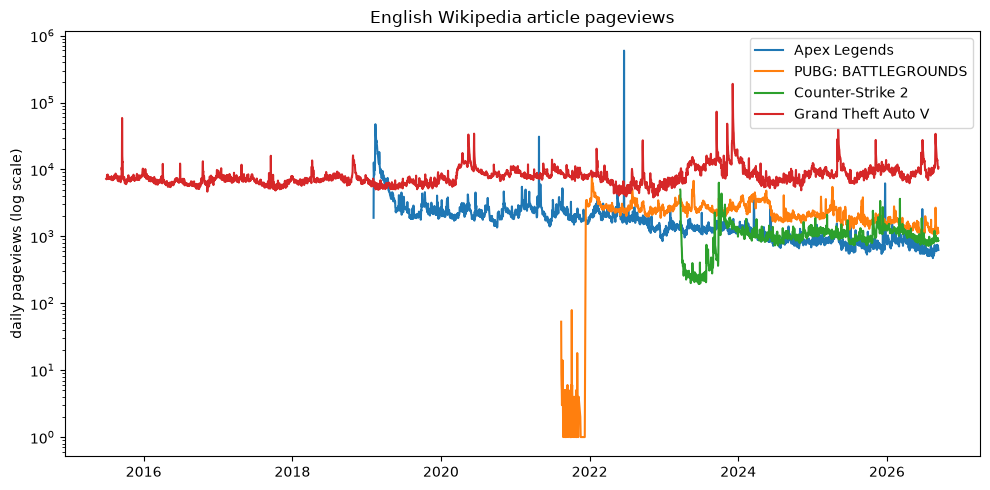

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for subject_id in SUBJECT_IDS:
    rows = conn.execute(
        "SELECT date, views FROM wikipedia_pageview_snapshots WHERE subject_id = ? ORDER BY date",
        (subject_id,),
    ).fetchall()
    if not rows:
        print(f"[info] {subject_id}: no Wikipedia pageview data")
        continue
    dates = pd.to_datetime([r[0] for r in rows], format="%Y%m%d")
    views = [r[1] for r in rows]
    ax.plot(dates, views, label=subjects[subject_id]["display_name"])
ax.set_yscale("log")
ax.set_ylabel("daily pageviews (log scale)")
ax.set_title("English Wikipedia article pageviews")
ax.legend()
plt.tight_layout()
plt.show()

## Signal 4 -- Steam review-language, and review-posting-time deconvolution

**Honest status, not overstated:** `collectors/steam_review_history_pull.py`
was smoke-tested against real data (confirmed working end-to-end) but a
full crawl has NOT been run -- Apex Legends alone has 1M+ reviews, and a
full historical crawl for even one subject is a multi-hour-to-multi-day
background job, the same category of task as `collectors/
steam_catalog_backfill.py`'s own "expect 1-2 weeks" Track A backfill.
`steam_review_history` currently holds only a ~100-review smoke-test
sample for `apex_legends` and nothing for the other subjects. Everything
below is a proof that the pipeline works, not a result to cite --
re-run after a real crawl.

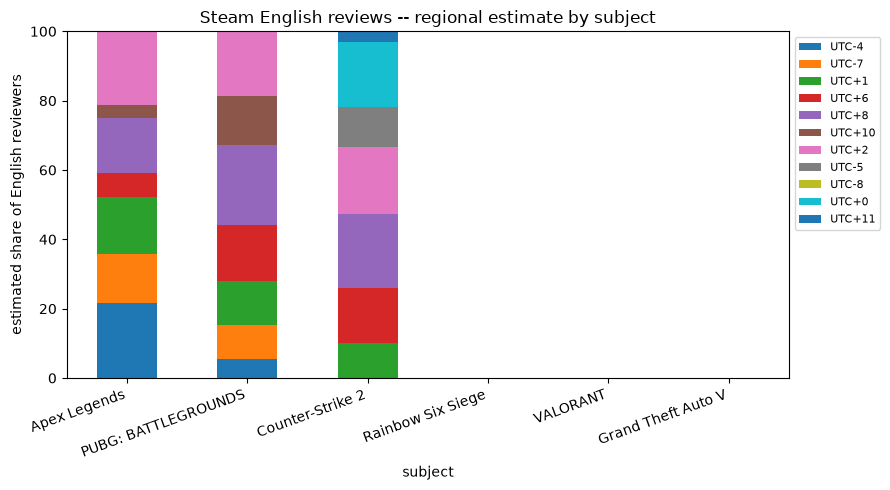

,english_reviews_in_history,total_reviews_crawled,UTC-4,UTC-7,UTC+1,UTC+6,UTC+8,UTC+10,UTC+2,UTC-5,UTC-8,UTC+0,UTC+11
subject,,,,,,,,,,,,,
Apex Legends,179145,591924,21.5,14.4,16.4,6.8,15.8,3.8,21.3,NaN,NaN,NaN,NaN
PUBG: BATTLEGROUNDS,62438,536953,5.6,9.8,12.6,16.0,23.1,14.3,18.6,NaN,NaN,NaN,NaN
Counter-Strike 2,263366,1100240,NaN,NaN,10.2,15.8,21.3,NaN,19.4,11.5,0.0,18.8,3.0
Rainbow Six Siege,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VALORANT,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grand Theft Auto V,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
steam_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    n_reviews = conn.execute(
        "SELECT COUNT(*) FROM steam_review_history WHERE subject_id = ?", (subject_id,)
    ).fetchone()[0]
    ws = conn.execute(
        "SELECT MIN(timestamp_created), MAX(timestamp_created) FROM steam_review_history WHERE subject_id = ? AND language = 'english'",
        (subject_id,),
    ).fetchone()
    hourly = get_steam_review_hourly_series(conn, subject)
    if ws[0] is None or hourly.sum() == 0:
        row = {"subject": subject["display_name"], "english_reviews_in_history": 0, "total_reviews_crawled": n_reviews}
        steam_rows.append(row)
        continue
    shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve, reference_datetime=_midpoint(ws[0], ws[1]))
    row = {"subject": subject["display_name"], "english_reviews_in_history": int(hourly.sum()), "total_reviews_crawled": n_reviews}
    row.update({country: round(share * 100, 1) for country, share in shares.items()})
    steam_rows.append(row)

steam_df = pd.DataFrame(steam_rows).set_index("subject")

fig, ax = plt.subplots(figsize=(9, 5))
steam_df.drop(columns=["english_reviews_in_history", "total_reviews_crawled"]).fillna(0).plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("estimated share of English reviewers")
ax.set_title("Steam English reviews -- regional estimate by subject")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
steam_df

## Counter-Strike cross-validation

The point of including `counter_strike` here:
`research/esports_lifecycle_and_maturity/notebooks/fastest_growing_cs_regions.ipynb` already found Russia (accelerating) and
Czech Republic (steady) as genuine grassroots-tournament growers, from
Liquipedia tournament records -- a completely different data source and
method than anything in this notebook. If Steam review-posting-time
(pooled across ALL languages, not just English -- this check is about
the whole playerbase's timing, not the English-speaking slice of it;
`get_steam_review_hourly_series(..., language=None)`) shows the same
Russia/CIS growth shape over the same years, that convergence between
two unrelated methods is real evidence.

**Crawl completed 2026-09-13 (1,100,240 reviews) -- but the result below
cannot actually test the grassroots-growth claim, and that's worth
stating plainly rather than reading too much into what IS there.**
Counter-Strike's crawl reached a much shorter window than Apex/PUBG's --
only 2025-07-14 to now (~14 months), for the same reason those two
notebooks now describe as title-specific and not a fixed depth (see
`research/inter_esports_dynamics/notebooks/steam_review_playerbase_over_time.ipynb`'s corrected note --
CS's own crawl actually covered *more* pages and reviews than either of
theirs, just compressed into far less calendar time, consistent with a
much higher review-posting velocity). `fastest_growing_cs_regions.ipynb`'s
finding is a multi-year trend (Russia accelerating across roughly a
decade of grassroots-tournament history) -- 14 months of Steam-review
data cannot confirm or refute a multi-year acceleration claim, full
stop. What the table below CAN show is only whether Russia currently
holds a large, stable share within this short window -- a much weaker
claim than the original cross-validation was scoped for.

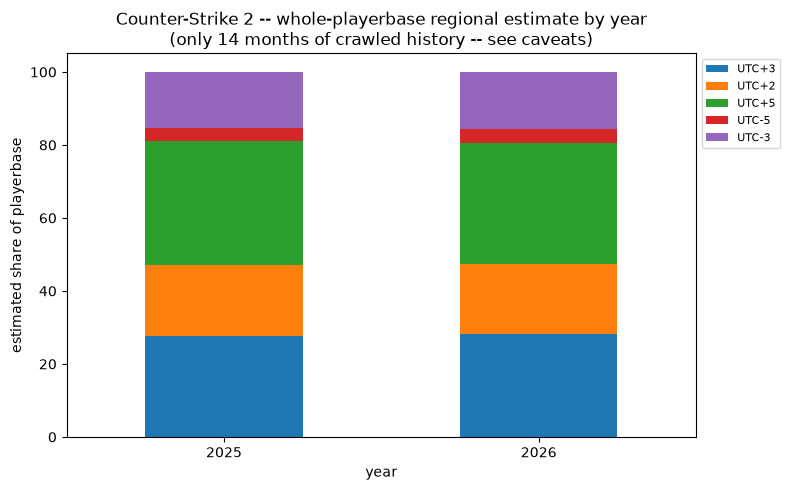

,reviews,UTC+3,UTC+2,UTC+5,UTC-5,UTC-3
year,,,,,,
2025,420077,27.6,19.6,33.9,3.5,15.5
2026,680163,28.3,19.2,33.1,3.8,15.6


In [7]:
# Not CANDIDATE_ENGLISH_COUNTRIES, since this question is about the whole
# playerbase, not the English-speaking slice. Listed separately (not
# pre-merged) the same way CANDIDATE_GLOBAL_COUNTRIES now is --
# decompose_by_timezone auto-merges Kazakhstan/Russia if they ever land
# on the same offset (they don't currently: Kazakhstan is UTC+5,
# Russia/Moscow is UTC+3), and Czech Republic/Western Europe whenever
# they're both in CET/CEST together, which is always (see module comment).
CS_CANDIDATE_COUNTRIES = {
    "Russia": "Europe/Moscow",
    "Czech_Republic": "Europe/Prague",
    "Western_Europe": "Europe/Berlin",
    "Kazakhstan": "Asia/Almaty",
    "North_America": "America/Chicago",
    "Brazil": "America/Sao_Paulo",
}

cs_subject = subjects["counter_strike"]
cs_yearly_rows = []
for year in range(2018, 2027):
    hourly = get_steam_review_hourly_series(conn, cs_subject, language=None, year=year)
    if hourly.sum() == 0:
        continue
    # July 2nd as a representative midpoint of the calendar year -- close
    # enough for a directional estimate; the exact day only matters right
    # around a DST transition boundary.
    reference_datetime = datetime(year, 7, 2, tzinfo=_tz.utc)
    shares = decompose_by_timezone(hourly, CS_CANDIDATE_COUNTRIES, calibration_curve=calibration_curve, reference_datetime=reference_datetime)
    cs_yearly_rows.append({"year": year, "reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})

if not cs_yearly_rows:
    print("No Counter-Strike Steam review data yet -- run collectors/steam_review_history_pull.py --subjects counter_strike --refresh first (a long-running background crawl, not a quick command).")
else:
    cs_df = pd.DataFrame(cs_yearly_rows).set_index("year")
    fig, ax = plt.subplots(figsize=(8, 5))
    cs_df.drop(columns="reviews").fillna(0).plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("estimated share of playerbase")
    ax.set_title("Counter-Strike 2 -- whole-playerbase regional estimate by year\n(only 14 months of crawled history -- see caveats)")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    display(cs_df)

## Persisting to `english_fandom_region_estimates`

Every share computed above, written to the synthesis table so a future
notebook/query doesn't have to re-derive them — `ai_assisted_unreviewed`
confidence throughout (an inferred estimate, never `verified`, per
CLAUDE.md's provenance rule). `window_start`/`window_end` mark the actual
data window each signal drew from, not today's date.

In [8]:
computed_at = datetime.now(_tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


def persist(subject_id, method, signal_source, window_start, window_end, shares):
    for region, share in shares.items():
        conn.execute(
            """
            INSERT INTO english_fandom_region_estimates
                (subject_id, region_or_country, window_start, window_end, method, signal_source, estimated_share, computed_at)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            ON CONFLICT (subject_id, region_or_country, window_start, window_end, method, signal_source)
            DO UPDATE SET estimated_share = excluded.estimated_share, computed_at = excluded.computed_at
            """,
            (subject_id, region, window_start, window_end, method, signal_source, share, computed_at),
        )


rows_persisted = 0
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]

    # Twitch timezone deconvolution -- window is language_mix_snapshots'/
    # platform_viewership_snapshots' own actual captured_at range.
    if subject["source_table"] == "viewership_snapshots":
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM language_mix_snapshots WHERE title_id = ?", (subject["title_id"],)).fetchone()
    else:
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM platform_viewership_snapshots WHERE game_id = ?", (subject["game_id"],)).fetchone()
    if w[0]:
        hourly = get_twitch_english_hourly_series(conn, subject)
        shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve, reference_datetime=_midpoint(w[0], w[1]))
        persist(subject_id, "timezone_deconvolution", "twitch_viewership", w[0], w[1], shares)
        rows_persisted += len(shares)

    # Tag mining -- normalized to a share of THIS subject's own tagged rows.
    row = next((r for r in tag_rows if r["subject"] == subject["display_name"]), None)
    if row:
        tag_counts = {k: v for k, v in row.items() if k != "subject" and v}
        total = sum(tag_counts.values())
        if total > 0 and w[0]:
            persist(subject_id, "tag_mining", "twitch_viewership", w[0], w[1], {k: v / total for k, v in tag_counts.items()})
            rows_persisted += len(tag_counts)

    # Steam review timezone deconvolution (English-only, matching Signal 4).
    ws = conn.execute("SELECT MIN(timestamp_created), MAX(timestamp_created) FROM steam_review_history WHERE subject_id = ? AND language = 'english'", (subject_id,)).fetchone()
    if ws[0]:
        window_start = datetime.fromtimestamp(ws[0], tz=_tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        window_end = datetime.fromtimestamp(ws[1], tz=_tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        hourly = get_steam_review_hourly_series(conn, subject)
        shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve, reference_datetime=_midpoint(ws[0], ws[1]))
        persist(subject_id, "timezone_deconvolution", "steam_reviews", window_start, window_end, shares)
        rows_persisted += len(shares)

# Counter-Strike yearly cross-validation, one row-set per year.
for entry in cs_yearly_rows:
    year = entry["year"]
    window_start, window_end = f"{year}-01-01T00:00:00Z", f"{year}-12-31T23:59:59Z"
    shares = {k: v / 100 for k, v in entry.items() if k not in ("year", "reviews")}
    persist("counter_strike", "timezone_deconvolution", "steam_reviews", window_start, window_end, shares)
    rows_persisted += len(shares)

conn.commit()
print(f"persisted {rows_persisted} estimate row(s) to english_fandom_region_estimates")

persisted 115 estimate row(s) to english_fandom_region_estimates


## Caveats -- read everything above as directional, not settled

- **Twitch English-viewer-time deconvolution** rests on a calibration
  curve built from only two languages (`ja`, `ko`) over the same short
  window every other notebook in this project already flags as a ~2-week
  snapshot, not a seasonally-averaged baseline. Re-run once
  `language_mix_snapshots` has months of history.
- **DST is handled properly as of 2026-09-14** (real IANA timezones via
  `zoneinfo`, resolved at each window's own midpoint -- see `analysis/
  fandom_region_decomposition.py`'s module docstring) -- fixed after
  confirming the old fixed-offset design was silently wrong for four of
  eight English candidates during this project's own Twitch collection
  window. Candidates that land on the identical resolved offset (always,
  like Japan/South_Korea, or only part of the year, like UK_Ireland/
  Nigeria during British Summer Time) are now auto-merged into one
  combined column rather than guessed apart -- **which column names
  appear can differ between runs, subjects, or even quarters of the same
  subject**, purely because the season changes which candidates are
  identifiable. That's a real, correct property of the underlying
  signal, not inconsistent output.
- **South Africa and Central Europe are structurally indistinguishable
  by this method for roughly seven months a year** (checked directly
  2026-09-14, in response to a direct question about exactly this) --
  South Africa observes no DST (fixed UTC+2 year-round); Central Europe
  is UTC+2 during CEST (late March-late October). Europe isn't currently
  a candidate in `CANDIDATE_ENGLISH_COUNTRIES`, so this doesn't show up
  as a live merge today, but it means `South_Africa`'s estimated share
  above should be read as "this share of the clock-time signal," which
  may include real Central European (or any other UTC+2-at-that-moment)
  activity this method has no way to strip out. No amount of further
  offset-tuning fixes this -- it needs a different signal (language,
  self-declared tags) to actually resolve.
- **Self-declared region tags are sparse by design** -- most streams
  carry no region marker at all; a subject with very few tagged streams
  should not be read as "has no international audience," only as
  "few streamers self-declared one."
- **Wikipedia pageviews cannot be timezone-deconvolved** (daily
  granularity only, confirmed against the live API while building this
  notebook) -- shown as an independent trend signal, not a region input.
- **Steam reviews are not a random sample, in either dimension --
  checked directly, not assumed.** Time: the crawl is a deterministic,
  most-recent-first walk that stops at a real, documented Steam
  cursor-pagination limit, not a sample spread across a title's whole
  history -- confirmed the reached window has zero gap days for all
  three crawled subjects, so it's a complete census of that period, then
  a hard cliff to nothing before it. Population: reviewers are
  self-selected (more-engaged players review more, sentiment is
  bimodal, review-prompt UI and regional norms can skew who shows up) --
  never "a random sample of who plays this game." Full detail in
  `analysis/fandom_region_decomposition.py`'s own module docstring.
- **The reached crawl window varies by title and is NOT a fixed
  constant** (corrected 2026-09-13, see
  `research/inter_esports_dynamics/notebooks/steam_review_playerbase_over_time.ipynb`) -- Counter-Strike's crawl
  reached only ~14 months of history despite the most pages/reviews of
  the three crawled titles, apparently because of its own much higher
  review-posting velocity, not a shared depth ceiling. Check
  `MIN(timestamp_created)` per subject before treating any date range as
  given.
- **The Counter-Strike cross-validation cannot actually confirm or
  refute `fastest_growing_cs_regions.ipynb`'s multi-year finding** --
  its 14-month window is too short to show year-over-year acceleration.
  See that section's own note.